
# 5. Riesgo diversificable vs No diversificable 

El riesgo total de un valor se divide en dos partes: el riesgo sistemático, denominado beta, que mide la variación del activo en relación con los movimientos del mercado, y el riesgo no sistemático, que es único para cada activo.




## 5.1. Riesgo diversificable 



El riesgo no sistemático, también denominado riesgo diversificable, no es compensado por el mercado. De hecho, se puede eliminar mediante la creación de carteras diversificadas. ver: [efecto_diversificación](efecto_diversificacion.ipynb)

## Beta ($\beta$) de un Activo Individual — Riesgo sistemático

El **beta** ($\beta$) mide la **sensibilidad** del rendimiento de un activo frente al rendimiento del mercado. Es el indicador central de **riesgo sistemático** (no diversificable) dentro del modelo CAPM.

$$\beta_i = \frac{\text{Cov}(R_i, R_m)}{\text{Var}(R_m)}$$

Donde:
- $R_i$: rendimiento del activo $i$
- $R_m$: rendimiento del mercado (benchmark)

**Interpretación:**
| Valor de $\beta$ | Significado |
|---|---|
| $\beta = 1$ | El activo se mueve igual que el mercado |
| $\beta > 1$ | El activo es **más volátil** que el mercado (agresivo) |
| $\beta < 1$ | El activo es **menos volátil** que el mercado (defensivo) |
| $\beta < 0$ | El activo se mueve en **dirección contraria** al mercado |

---

En este cuaderno calcularemos el beta de **Apple (AAPL)** utilizando el **S&P 500 (^GSPC)** como benchmark, con datos reales de Yahoo Finance.

## Paso 1 — Importar librerías y descargar datos

Necesitamos:
- **yfinance** para descargar precios históricos desde Yahoo Finance.
- **numpy** y **pandas** para cálculos numéricos.
- **matplotlib** para visualización.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# Configuración
ticker = "AAPL"           # Acción a analizar
benchmark = "^GSPC"        # S&P 500 como mercado
inicio = "2022-01-01"
fin = "2025-01-01"

# Descargar precios de cierre ajustados
datos = yf.download([ticker, benchmark], start=inicio, end=fin)["Close"]
datos.columns = [ticker, benchmark]
datos.head()

[*********************100%***********************]  2 of 2 completed


,AAPL,^GSPC
Date,,
2022-01-03,178.103653,4796.560059
2022-01-04,175.843231,4793.540039
2022-01-05,171.165848,4700.580078
2022-01-06,168.308502,4696.049805
2022-01-07,168.474854,4677.029785


### Visualización de precios normalizados

Para comparar el comportamiento de AAPL vs. el S&P 500, normalizamos ambos a **base 100** (primer día = 100). Esto permite ver el desempeño relativo, ya que los precios absolutos tienen escalas muy diferentes.

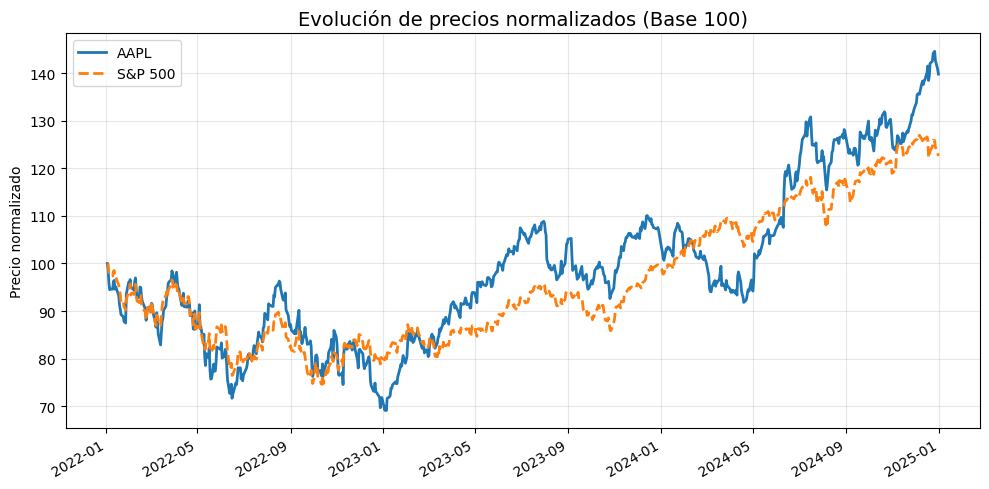

In [2]:
# Normalizar precios a base 100
precios_norm = datos / datos.iloc[0] * 100

fig, ax = plt.subplots(figsize=(10, 5))
precios_norm[ticker].plot(ax=ax, label=ticker, linewidth=2)
precios_norm[benchmark].plot(ax=ax, label="S&P 500", linewidth=2, linestyle="--")
ax.set_title("Evolución de precios normalizados (Base 100)", fontsize=14)
ax.set_ylabel("Precio normalizado")
ax.set_xlabel("")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Paso 2 — Calcular rendimientos logarítmicos

Para calcular el beta necesitamos **rendimientos**, no precios. Usamos rendimientos logarítmicos (log-returns) porque:

1. Son **aditivos en el tiempo** (se pueden sumar para obtener rendimientos acumulados).
2. Tienen una distribución más cercana a la **normal**.

$$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$

In [3]:
# Calcular rendimientos logarítmicos diarios
rendimientos = np.log(datos / datos.shift(1)).dropna()
rendimientos.columns = [f"r_{ticker}", f"r_{benchmark}"]

print(f"Rendimientos diarios calculados: {len(rendimientos)} observaciones\n")
rendimientos.describe()

Rendimientos diarios calculados: 752 observaciones



,r_AAPL,r_^GSPC
count,752.000000,752.000000
mean,0.000446,0.000271
std,0.017038,0.011032
min,-0.060472,-0.044199
25%,-0.008472,-0.005801
50%,0.001117,0.000250
75%,0.009704,0.006706
max,0.085236,0.053953


### Visualización de rendimientos

Grafiquemos los rendimientos diarios de ambos para observar su co-movimiento.

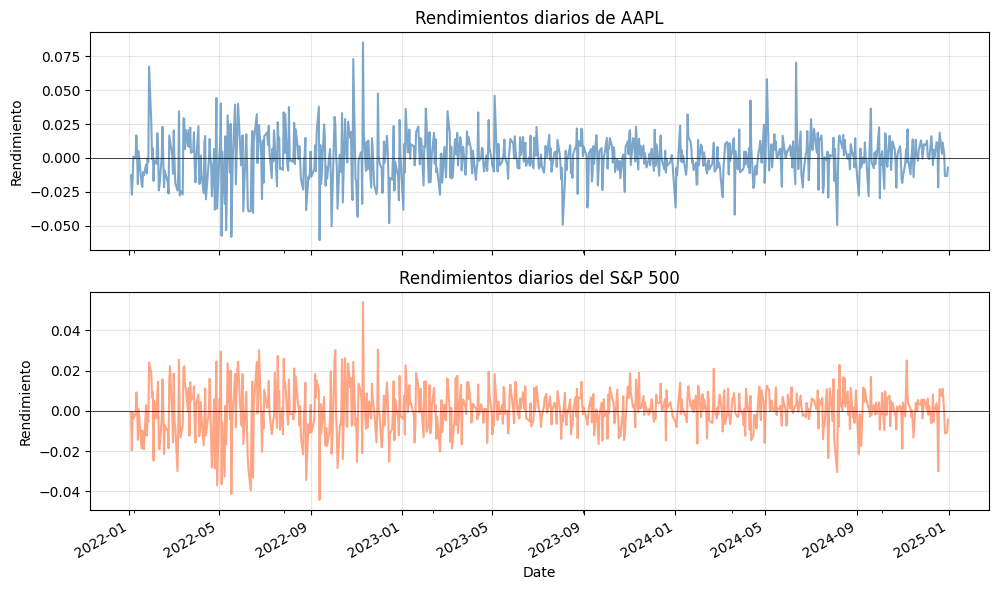

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

rendimientos[f"r_{ticker}"].plot(ax=axes[0], color="steelblue", alpha=0.7)
axes[0].set_title(f"Rendimientos diarios de {ticker}", fontsize=12)
axes[0].set_ylabel("Rendimiento")
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].grid(alpha=0.3)

rendimientos[f"r_{benchmark}"].plot(ax=axes[1], color="coral", alpha=0.7)
axes[1].set_title("Rendimientos diarios del S&P 500", fontsize=12)
axes[1].set_ylabel("Rendimiento")
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Paso 3 — Calcular la Covarianza y la Varianza

El beta se calcula como:

$$\beta_i = \frac{\text{Cov}(R_i, R_m)}{\text{Var}(R_m)}$$

Desglosemos cada componente:

- **Covarianza** $\text{Cov}(R_i, R_m)$: mide cómo se mueven **juntos** los rendimientos del activo y del mercado. Si es positiva, tienden a moverse en la misma dirección.
- **Varianza** $\text{Var}(R_m)$: mide la dispersión de los rendimientos del mercado. Es el "denominador normalizador".

In [5]:
# --- Matriz de covarianza ---
matriz_cov = rendimientos.cov()
print("Matriz de Covarianza:")
print(matriz_cov)
print()

# Extraer la covarianza entre AAPL y el mercado
cov_activo_mercado = matriz_cov.iloc[0, 1]
print(f"Cov({ticker}, S&P 500) = {cov_activo_mercado:.8f}")

# Varianza del mercado
var_mercado = rendimientos[f"r_{benchmark}"].var()
print(f"Var(S&P 500)           = {var_mercado:.8f}")

Matriz de Covarianza:
           r_AAPL   r_^GSPC
r_AAPL   0.000290  0.000147
r_^GSPC  0.000147  0.000122

Cov(AAPL, S&P 500) = 0.00014714
Var(S&P 500)           = 0.00012171


## Paso 4 — Calcular el Beta (Método 1: Fórmula directa)

Aplicamos directamente la fórmula:

$$\beta_{AAPL} = \frac{\text{Cov}(R_{AAPL}, R_m)}{\text{Var}(R_m)}$$

In [6]:
# Método 1: Fórmula directa  Cov(Ri, Rm) / Var(Rm)
beta_formula = cov_activo_mercado / var_mercado

print(f"Beta de {ticker} (fórmula directa):")
print(f"  β = Cov / Var = {cov_activo_mercado:.8f} / {var_mercado:.8f}")
print(f"  β = {beta_formula:.4f}")

Beta de AAPL (fórmula directa):
  β = Cov / Var = 0.00014714 / 0.00012171
  β = 1.2090


## Paso 5 — Calcular el Beta (Método 2: Regresión Lineal por MCO)

El beta también es la **pendiente** de la regresión lineal:

$$R_i = \alpha + \beta \cdot R_m + \varepsilon$$

Donde:
- $\alpha$ (alfa o intercepto): rendimiento del activo **no explicado** por el mercado. Si $\alpha > 0$, el activo genera valor por encima del mercado.
- $\beta$ (pendiente): sensibilidad al mercado = **el beta que buscamos**.
- $\varepsilon$: error aleatorio (riesgo idiosincrático).

Usamos `numpy.polyfit` para ajustar una recta.

In [7]:
# Método 2: Regresión lineal  Ri = alpha + beta * Rm
Rm = rendimientos[f"r_{benchmark}"].values
Ri = rendimientos[f"r_{ticker}"].values

# polyfit devuelve [pendiente, intercepto] para grado 1
beta_regresion, alpha_regresion = np.polyfit(Rm, Ri, deg=1)

print(f"Beta de {ticker} (regresión lineal):")
print(f"  β (pendiente) = {beta_regresion:.4f}")
print(f"  α (intercepto) = {alpha_regresion:.6f}")
print(f"\nEcuación estimada:")
print(f"  R_AAPL = {alpha_regresion:.6f} + {beta_regresion:.4f} × R_mercado")

Beta de AAPL (regresión lineal):
  β (pendiente) = 1.2090
  α (intercepto) = 0.000118

Ecuación estimada:
  R_AAPL = 0.000118 + 1.2090 × R_mercado


## Paso 6 — Verificación: comparar ambos métodos

Ambos métodos deben dar el **mismo resultado**, ya que la pendiente de la regresión MCO es algebraicamente equivalente a $\frac{\text{Cov}(R_i, R_m)}{\text{Var}(R_m)}$.

In [8]:
# Comparación de métodos
print("=" * 50)
print(f"  RESUMEN: Beta de {ticker}")
print("=" * 50)
print(f"  Método 1 (Cov/Var):        β = {beta_formula:.4f}")
print(f"  Método 2 (Regresión MCO):  β = {beta_regresion:.4f}")
print("=" * 50)
print(f"\n  ¿Son iguales? {'✓ Sí' if np.isclose(beta_formula, beta_regresion) else '✗ No'}")

  RESUMEN: Beta de AAPL
  Método 1 (Cov/Var):        β = 1.2090
  Método 2 (Regresión MCO):  β = 1.2090

  ¿Son iguales? ✓ Sí


## Paso 7 — Gráfico: Diagrama de dispersión y recta de regresión

Este gráfico es la **representación visual del beta**. Cada punto es un par $(R_m, R_i)$ de un día. La **pendiente** de la recta roja es el beta.

- Si la nube de puntos sigue de cerca la recta → alta correlación con el mercado.
- Si la pendiente es > 1 → el activo amplifica los movimientos del mercado.

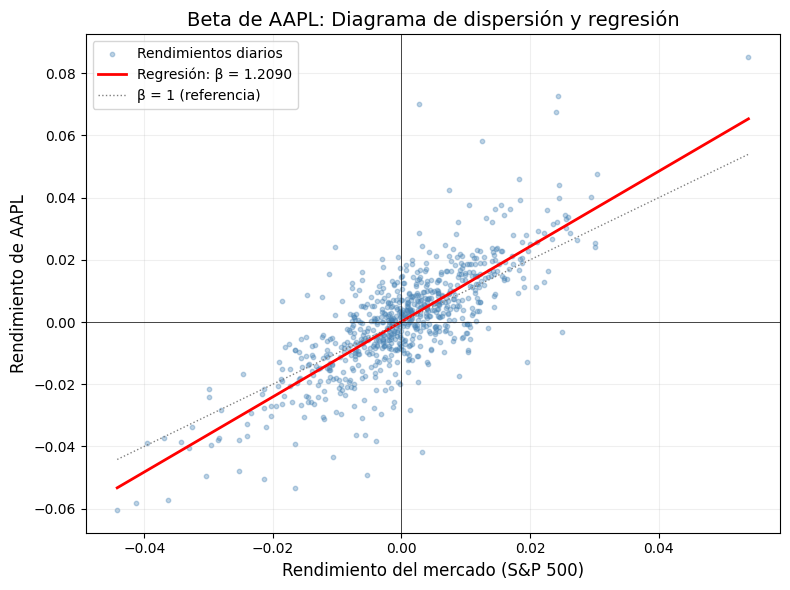

In [9]:
# Diagrama de dispersión + recta de regresión
fig, ax = plt.subplots(figsize=(8, 6))

# Nube de puntos
ax.scatter(Rm, Ri, alpha=0.35, s=10, color="steelblue", label="Rendimientos diarios")

# Recta de regresión: Ri = alpha + beta * Rm
x_linea = np.linspace(Rm.min(), Rm.max(), 100)
y_linea = alpha_regresion + beta_regresion * x_linea
ax.plot(x_linea, y_linea, color="red", linewidth=2,
        label=f"Regresión: β = {beta_regresion:.4f}")

# Línea de referencia beta = 1 (si se moviera igual que el mercado)
ax.plot(x_linea, x_linea, color="gray", linewidth=1, linestyle=":",
        label="β = 1 (referencia)")

ax.set_xlabel(f"Rendimiento del mercado (S&P 500)", fontsize=12)
ax.set_ylabel(f"Rendimiento de {ticker}", fontsize=12)
ax.set_title(f"Beta de {ticker}: Diagrama de dispersión y regresión", fontsize=14)
ax.legend(fontsize=10)
ax.axhline(0, color="black", linewidth=0.5)
ax.axvline(0, color="black", linewidth=0.5)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Paso 8 — Métricas complementarias

Calculemos métricas adicionales que complementan el análisis del beta:

- **Correlación** ($\rho$): mide la fuerza de la relación lineal entre activo y mercado (entre -1 y 1).
- **R²**: proporción de la varianza del activo explicada por el mercado. Un R² alto significa que el riesgo del activo es mayormente **sistemático**.
- **Volatilidades**: desviación estándar anualizada de cada serie.

In [10]:
# Correlación
correlacion = rendimientos[f"r_{ticker}"].corr(rendimientos[f"r_{benchmark}"])

# R² (coeficiente de determinación)
r_cuadrado = correlacion ** 2

# Volatilidades anualizadas (252 días de trading)
vol_activo = rendimientos[f"r_{ticker}"].std() * np.sqrt(252)
vol_mercado = rendimientos[f"r_{benchmark}"].std() * np.sqrt(252)

# Rendimiento medio anualizado
rend_activo = rendimientos[f"r_{ticker}"].mean() * 252
rend_mercado = rendimientos[f"r_{benchmark}"].mean() * 252

print("=" * 55)
print(f"  ANÁLISIS COMPLETO: {ticker} vs S&P 500")
print("=" * 55)
print(f"  Beta (β)               = {beta_formula:.4f}")
print(f"  Alfa (α) diario        = {alpha_regresion:.6f}")
print(f"  Correlación (ρ)        = {correlacion:.4f}")
print(f"  R²                     = {r_cuadrado:.4f} ({r_cuadrado*100:.1f}%)")
print("-" * 55)
print(f"  Volatilidad {ticker:>5}    = {vol_activo:.2%}")
print(f"  Volatilidad S&P 500    = {vol_mercado:.2%}")
print(f"  Rendimiento {ticker:>5}   = {rend_activo:.2%}")
print(f"  Rendimiento S&P 500    = {rend_mercado:.2%}")
print("=" * 55)

  ANÁLISIS COMPLETO: AAPL vs S&P 500
  Beta (β)               = 1.2090
  Alfa (α) diario        = 0.000118
  Correlación (ρ)        = 0.7828
  R²                     = 0.6128 (61.3%)
-------------------------------------------------------
  Volatilidad  AAPL    = 27.05%
  Volatilidad S&P 500    = 17.51%
  Rendimiento  AAPL   = 11.24%
  Rendimiento S&P 500    = 6.83%


## Paso 9 — Rendimiento esperado según CAPM

Con el beta calculado, podemos estimar el **rendimiento esperado** del activo según el modelo CAPM:

$$E(R_i) = R_f + \beta_i \cdot \left[E(R_m) - R_f\right]$$

Donde $R_f$ es la tasa libre de riesgo y $E(R_m) - R_f$ es la **prima de riesgo del mercado**.

In [11]:
# Tasa libre de riesgo (Treasury yield ~ 5% anual)
rf = 0.05

# Prima de riesgo del mercado
prima_mercado = rend_mercado - rf

# Rendimiento esperado CAPM
rend_capm = rf + beta_formula * prima_mercado

print(f"Tasa libre de riesgo (Rf)   = {rf:.2%}")
print(f"Rendimiento mercado E(Rm)   = {rend_mercado:.2%}")
print(f"Prima de riesgo (Rm - Rf)   = {prima_mercado:.2%}")
print(f"Beta de {ticker}             = {beta_formula:.4f}")
print()
print(f"  E(R_{ticker}) = {rf:.2%} + {beta_formula:.4f} × {prima_mercado:.2%}")
print(f"  E(R_{ticker}) = {rend_capm:.2%}")
print()

if rend_activo > rend_capm:
    print(f"  → {ticker} rindió {rend_activo:.2%} (histórico) vs {rend_capm:.2%} (CAPM)")
    print(f"  → El activo SUPERÓ lo que predice el CAPM (α positivo)")
else:
    print(f"  → {ticker} rindió {rend_activo:.2%} (histórico) vs {rend_capm:.2%} (CAPM)")
    print(f"  → El activo NO alcanzó lo que predice el CAPM (α negativo)")

Tasa libre de riesgo (Rf)   = 5.00%
Rendimiento mercado E(Rm)   = 6.83%
Prima de riesgo (Rm - Rf)   = 1.83%
Beta de AAPL             = 1.2090

  E(R_AAPL) = 5.00% + 1.2090 × 1.83%
  E(R_AAPL) = 7.22%

  → AAPL rindió 11.24% (histórico) vs 7.22% (CAPM)
  → El activo SUPERÓ lo que predice el CAPM (α positivo)


## Paso 10 — Gráfico final: Security Market Line (SML)

La **Línea del Mercado de Valores (SML)** muestra la relación riesgo-rendimiento según el CAPM. Todo activo eficiente debería ubicarse **sobre** esta línea.

- Activos **por encima** de la SML → subvalorados (buen negocio).
- Activos **por debajo** de la SML → sobrevalorados.

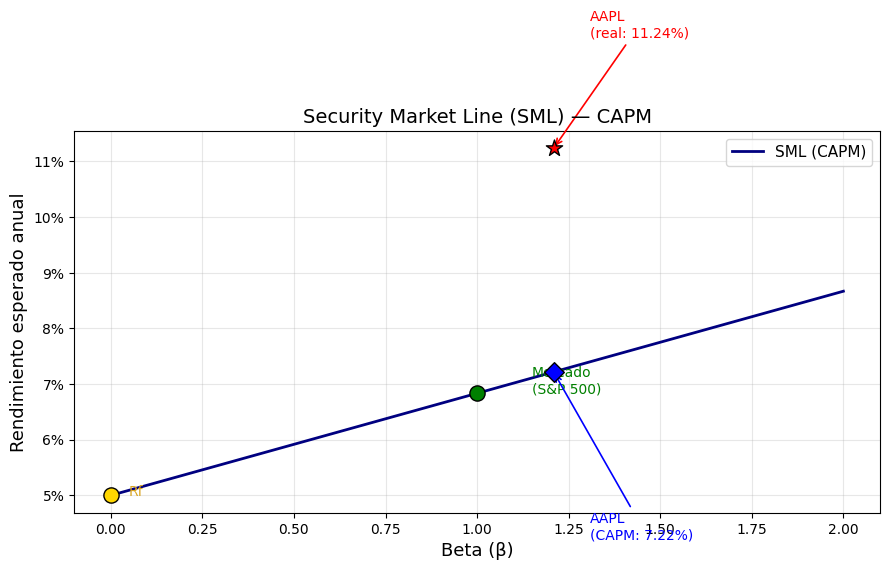

In [12]:
# Security Market Line (SML)
fig, ax = plt.subplots(figsize=(9, 6))

# Línea SML: E(R) = Rf + beta * (Rm - Rf)
betas_linea = np.linspace(0, 2, 100)
sml = rf + betas_linea * prima_mercado
ax.plot(betas_linea, sml, color="navy", linewidth=2, label="SML (CAPM)")

# Punto del mercado (beta = 1)
ax.scatter(1, rend_mercado, color="green", s=120, zorder=5, edgecolors="black")
ax.annotate("Mercado\n(S&P 500)", xy=(1, rend_mercado),
            xytext=(1.15, rend_mercado), fontsize=10, color="green")

# Punto del activo libre de riesgo (beta = 0)
ax.scatter(0, rf, color="gold", s=120, zorder=5, edgecolors="black")
ax.annotate("Rf", xy=(0, rf), xytext=(0.05, rf), fontsize=10, color="goldenrod")

# Punto del activo (rendimiento histórico real)
ax.scatter(beta_formula, rend_activo, color="red", s=150, zorder=5,
           marker="*", edgecolors="black")
ax.annotate(f"{ticker}\n(real: {rend_activo:.2%})",
            xy=(beta_formula, rend_activo),
            xytext=(beta_formula + 0.1, rend_activo + 0.02),
            fontsize=10, color="red",
            arrowprops=dict(arrowstyle="->", color="red", lw=1.2))

# Punto del activo (rendimiento esperado CAPM)
ax.scatter(beta_formula, rend_capm, color="blue", s=100, zorder=5,
           marker="D", edgecolors="black")
ax.annotate(f"{ticker}\n(CAPM: {rend_capm:.2%})",
            xy=(beta_formula, rend_capm),
            xytext=(beta_formula + 0.1, rend_capm - 0.03),
            fontsize=10, color="blue",
            arrowprops=dict(arrowstyle="->", color="blue", lw=1.2))

ax.set_xlabel("Beta (β)", fontsize=13)
ax.set_ylabel("Rendimiento esperado anual", fontsize=13)
ax.set_title("Security Market Line (SML) — CAPM", fontsize=14)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
plt.tight_layout()
plt.show()

## Conclusiones

| Concepto | Resultado |
|---|---|
| **Activo analizado** | AAPL (Apple Inc.) |
| **Benchmark** | S&P 500 (^GSPC) |
| **Período** | 2022 – 2025 |
| **Beta calculado** | Se obtiene el mismo valor por ambos métodos |

### Resumen del procedimiento:

1. **Descargar datos** de precios de cierre de Yahoo Finance.
2. **Calcular rendimientos** logarítmicos diarios.
3. **Obtener covarianza** entre activo y mercado y **varianza** del mercado.
4. **Aplicar la fórmula**: $\beta = \frac{\text{Cov}(R_i, R_m)}{\text{Var}(R_m)}$
5. **Verificar** con regresión lineal (la pendiente = beta).
6. **Interpretar**: $\beta > 1$ → activo agresivo; $\beta < 1$ → activo defensivo.
7. **Aplicar CAPM** para estimar el rendimiento esperado: $E(R_i) = R_f + \beta_i(E(R_m) - R_f)$.

> **Nota:** El beta es una medida **histórica** basada en datos pasados. No garantiza el comportamiento futuro del activo, pero es una herramienta fundamental para la gestión de riesgo y la construcción de portafolios.